Alexander Faust
May 10, 2025
Stochastic Calculus Problem Set

This script relied on the use of Claude 3.7 Sonnet for generation purposes. I have modified sections of its output depending on the quality of output.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from matplotlib import cm
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

# Simulation parameters
delta = 1/260  # Daily timestep (260 trading days per year)
N = 520        # Total timesteps (2 years)
T = N * delta  # Total time (2 years)
S0 = 1.0       # Initial stock price
alpha = 0.1    # Drift parameter
r = 0.05       # Interest rate
sigma_values = [0.05, 0.1, 0.3]  # Volatility values to test

-------------------
## Part 2 : Simulating Stochastic Differential Equations
-------------------

In [ ]:
# Part (a)
def simulate_gbm(S0, alpha, sigma, T, N, num_paths=100, validate=True):
    """
    Simulate geometric Brownian motion: dS_t = alpha*S_t*dt + sigma*S_t*dW_t
    
    Parameters:
    - S0: Initial stock price
    - alpha: Drift parameter
    - sigma: Volatility parameter
    - T: Time horizon
    - N: Number of time steps
    - num_paths: Number of simulation paths
    - validate: If True, check for and reject negative paths
    
    Returns:
    - time_grid: Array of time points
    - S: Array of simulated stock prices (paths x time points)
    - bad_paths_count: Number of rejected paths (if validate=True)
    """
    delta = T/N
    time_grid = np.linspace(0, T, N+1)
    
    valid_paths = 0
    bad_paths_count = 0
    S = np.zeros((num_paths, N+1))
    
    while valid_paths < num_paths:
        # Generate a single path
        path = np.zeros(N+1)
        path[0] = S0
        
        # Generate increments
        dW = np.random.normal(0, np.sqrt(delta), N)
        
        # Simulate the path
        for n in range(N):
            path[n+1] = path[n] + alpha * path[n] * delta + sigma * path[n] * dW[n]
        
        # Check if path has negative values
        if validate and any(path <= 0):
            bad_paths_count += 1
            continue
        
        # Add valid path to the collection
        S[valid_paths] = path
        valid_paths += 1

        if valid_paths % 100 == 0 and valid_paths > 0:
            print(f"Generated {valid_paths} valid paths out of {num_paths}")
    
    print(f"Completed simulation. Bad paths rejected: {bad_paths_count}")
    return time_grid, S, bad_paths_count

In [13]:
# Part (b)
def derive_risk_neutral_sde(alpha, sigma, r):
    """
    Calculate and display the risk-neutral SDE coefficients
    """
    print(f"Original SDE: dS_t = {alpha}*S_t*dt + {sigma}*S_t*dW_t")
    print(f"Risk-neutral SDE: dS_t = {r}*S_t*dt + {sigma}*S_t*dW̃_t")
    
    # Calculate risk premium (market price of risk)
    risk_premium = (alpha - r) / sigma
    print(f"Risk premium (market price of risk): {risk_premium:.4f}")
    
    return r, sigma

In [14]:
# Part (c)
def simulate_all_sigma_values(S0, alpha, r, sigma_values, T, N, num_paths=1000):
    """
    Simulate GBM for all sigma values and plot sample paths
    """
    results = {}
    
    for sigma in sigma_values:
        print(f"\nSimulating with σ = {sigma}:")
        time_grid, S, bad_paths = simulate_gbm(S0, alpha, sigma, T, N, num_paths)
        results[sigma] = {'time': time_grid, 'paths': S, 'bad_paths': bad_paths}
        
        # Plot first 10 sample paths
        plt.figure(figsize=(12, 6))
        for i in range(min(10, num_paths)):
            plt.plot(time_grid, S[i])
        
        plt.title(f'Sample Paths for GBM with σ = {sigma}')
        plt.xlabel('Time (years)')
        plt.ylabel('Stock Price')
        plt.grid(True)
        plt.show()
    
    return results

In [15]:
# Part (d)
def estimate_expectations(results, sigma_values):
    """
    Estimate E(S[N/2]) and E(S[N]) and compare with theoretical values
    """
    N = len(results[sigma_values[0]]['time']) - 1
    mid_point = N // 2
    final_point = N
    T = results[sigma_values[0]]['time'][-1]
    
    print("\nMonte Carlo Estimates vs. Theoretical Values:")
    print("Sigma | Time | MC Estimate | Theoretical | Difference (%)")
    print("-" * 60)
    
    for sigma in sigma_values:
        paths = results[sigma]['paths']
        
        # Midpoint expectations
        mid_mc = np.mean(paths[:, mid_point])
        mid_theory = S0 * np.exp(alpha * (T/2))
        mid_diff = abs((mid_mc - mid_theory) / mid_theory) * 100
        
        # Final expectations
        final_mc = np.mean(paths[:, final_point])
        final_theory = S0 * np.exp(alpha * T)
        final_diff = abs((final_mc - final_theory) / final_theory) * 100
        
        print(f"{sigma:.2f} | T/2   | {mid_mc:.6f}   | {mid_theory:.6f}   | {mid_diff:.4f}%")
        print(f"{sigma:.2f} | T     | {final_mc:.6f}   | {final_theory:.6f}   | {final_diff:.4f}%")
    
    return None

In [16]:
# Part (e)
def black_scholes_call(S, K, r, sigma, tau):
    """
    Calculate the Black-Scholes price of a European call option
    
    Parameters:
    - sigma: Volatility
    - tau: Time to maturity (in years)
    
    Returns:
    - call_price: Price of the call option
    """
    # Calculate Black-Scholes parameters
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    
    # Calculate option price
    call_price = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    
    return call_price

def plot_bs_option_values(S0, r, sigma_values, T):
    """
    Plot the Black-Scholes call option values as a function of S[N/2]
    """
    # Calculate strike price
    K = S0 * np.exp(r * T)
    
    # Create range of S[N/2] values
    S_mid_values = np.linspace(0.5, 2.0, 100)
    
    plt.figure(figsize=(12, 8))
    
    for sigma in sigma_values:
        # Calculate option values for each S[N/2]
        option_values = [black_scholes_call(S_mid, K, r, sigma, T/2) for S_mid in S_mid_values]
        
        # Plot the curve
        plt.plot(S_mid_values, option_values, label=f'σ = {sigma}')
    
    plt.title('Black-Scholes Call Option Values at t=T/2')
    plt.xlabel('Stock Price at t=T/2')
    plt.ylabel('Option Value V[N/2]')
    plt.legend()
    plt.grid(True)
    plt.show()

In [17]:
# Part (f)
def compare_bs_vs_mc(results, S0, r, sigma_values, T, N):
    """
    Compare Black-Scholes values with Monte Carlo estimates for specific paths
    """
    # Calculate strike price
    K = S0 * np.exp(r * T)
    mid_point = N // 2
    
    # Create table to store results
    table = []
    
    for sigma in sigma_values:
        paths = results[sigma]['paths']
        
        # Take the first 10 paths
        for i in range(min(10, len(paths))):
            S_mid = paths[i, mid_point]
            
            # Calculate BS value at t=T/2
            bs_value = black_scholes_call(S_mid, K, r, sigma, T/2)
            
            # Calculate Monte Carlo estimate:
            # 1. Simulate new paths from S_mid to final time using risk-neutral drift
            _, mc_paths, _ = simulate_gbm(
                S_mid, r, sigma, T/2, N//2, num_paths=1000, validate=False
            )
            
            # 2. Calculate payoffs and discount
            payoffs = np.maximum(mc_paths[:, -1] - K, 0)
            mc_value = np.mean(payoffs) * np.exp(-r * (T/2))
            
            # Add to table
            table.append({
                'Sigma': sigma,
                'Path': i+1,
                'S[N/2]': S_mid,
                'BS Value': bs_value,
                'MC Value': mc_value,
                'Diff (%)': abs((bs_value - mc_value) / bs_value) * 100
            })
    
    # Create and display DataFrame
    df = pd.DataFrame(table)
    print(df)
    
    # Create scatter plots
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 2, 1)
    for sigma in sigma_values:
        df_sigma = df[df['Sigma'] == sigma]
        plt.scatter(df_sigma['S[N/2]'], df_sigma['BS Value'], 
                   label=f'BS (σ={sigma})', alpha=0.7)
    
    plt.title('Black-Scholes Values vs S[N/2]')
    plt.xlabel('Stock Price at t=T/2')
    plt.ylabel('Option Value')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    for sigma in sigma_values:
        df_sigma = df[df['Sigma'] == sigma]
        plt.scatter(df_sigma['S[N/2]'], df_sigma['MC Value'], 
                   label=f'MC (σ={sigma})', alpha=0.7)
    
    plt.title('Monte Carlo Values vs S[N/2]')
    plt.xlabel('Stock Price at t=T/2')
    plt.ylabel('Option Value')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return df

Strike price K = 1.1052

For σ = 0.05:
Original SDE: dS_t = 0.1*S_t*dt + 0.05*S_t*dW_t
Risk-neutral SDE: dS_t = 0.05*S_t*dt + 0.05*S_t*dW̃_t
Risk premium (market price of risk): 1.0000

For σ = 0.1:
Original SDE: dS_t = 0.1*S_t*dt + 0.1*S_t*dW_t
Risk-neutral SDE: dS_t = 0.05*S_t*dt + 0.1*S_t*dW̃_t
Risk premium (market price of risk): 0.5000

For σ = 0.3:
Original SDE: dS_t = 0.1*S_t*dt + 0.3*S_t*dW_t
Risk-neutral SDE: dS_t = 0.05*S_t*dt + 0.3*S_t*dW̃_t
Risk premium (market price of risk): 0.1667

Simulating with σ = 0.05:
Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 1000
Generated 500 valid paths out of 1000
Generated 600 valid paths out of 1000
Generated 700 valid paths out of 1000
Generated 800 valid paths out of 1000
Generated 900 valid paths out of 1000
Generated 1000 valid paths out of 1000
Completed simulation. Bad paths rejected: 0


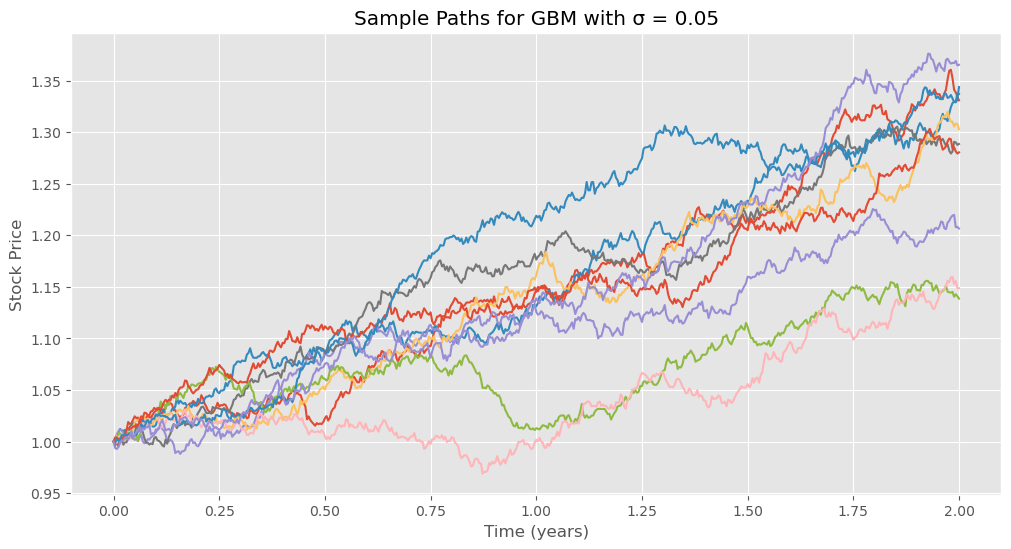


Simulating with σ = 0.1:
Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 1000
Generated 500 valid paths out of 1000
Generated 600 valid paths out of 1000
Generated 700 valid paths out of 1000
Generated 800 valid paths out of 1000
Generated 900 valid paths out of 1000
Generated 1000 valid paths out of 1000
Completed simulation. Bad paths rejected: 0


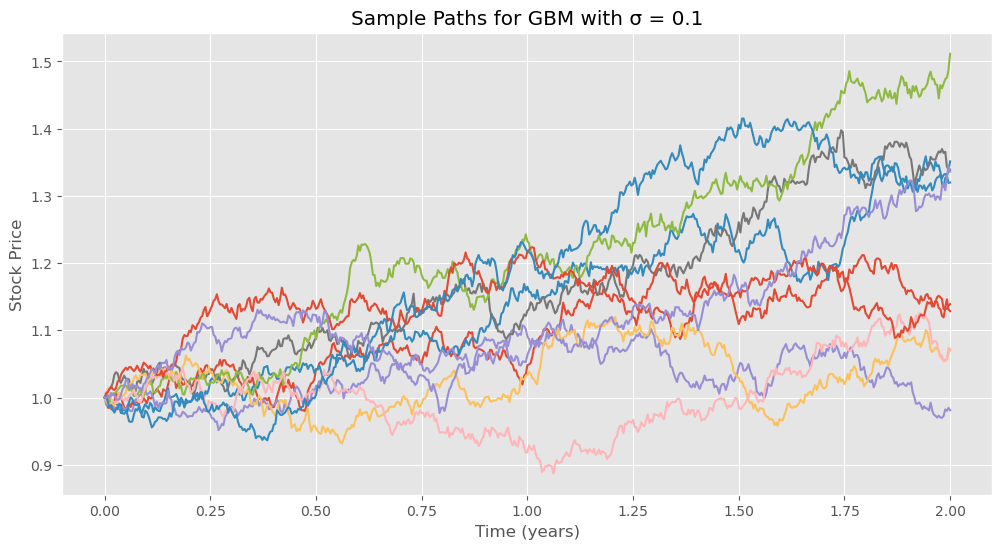


Simulating with σ = 0.3:
Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 1000
Generated 500 valid paths out of 1000
Generated 600 valid paths out of 1000
Generated 700 valid paths out of 1000
Generated 800 valid paths out of 1000
Generated 900 valid paths out of 1000
Generated 1000 valid paths out of 1000
Completed simulation. Bad paths rejected: 0


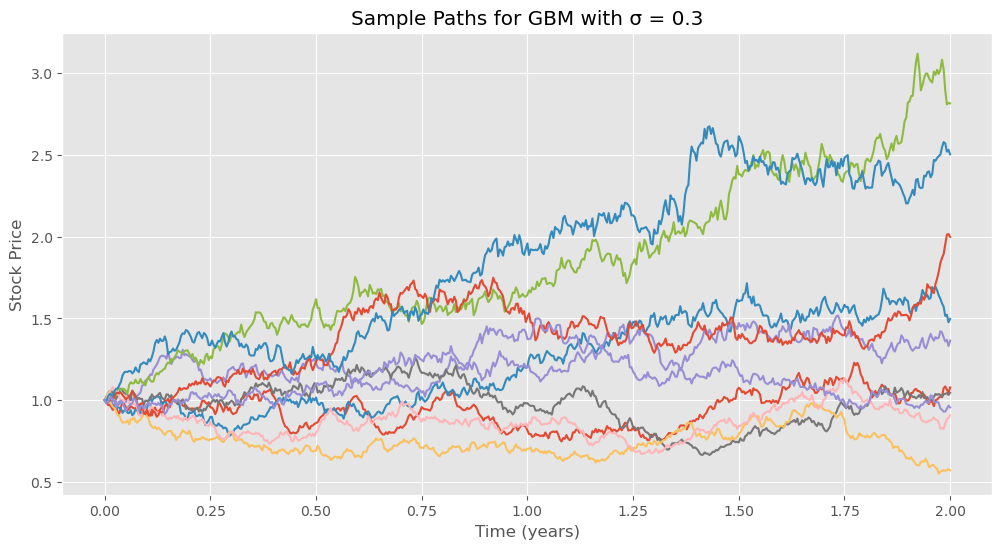


Monte Carlo Estimates vs. Theoretical Values:
Sigma | Time | MC Estimate | Theoretical | Difference (%)
------------------------------------------------------------
0.05 | T/2   | 1.108956   | 1.105171   | 0.3425%
0.05 | T     | 1.228557   | 1.221403   | 0.5857%
0.10 | T/2   | 1.111359   | 1.105171   | 0.5599%
0.10 | T     | 1.230180   | 1.221403   | 0.7186%
0.30 | T/2   | 1.106639   | 1.105171   | 0.1328%
0.30 | T     | 1.251057   | 1.221403   | 2.4279%


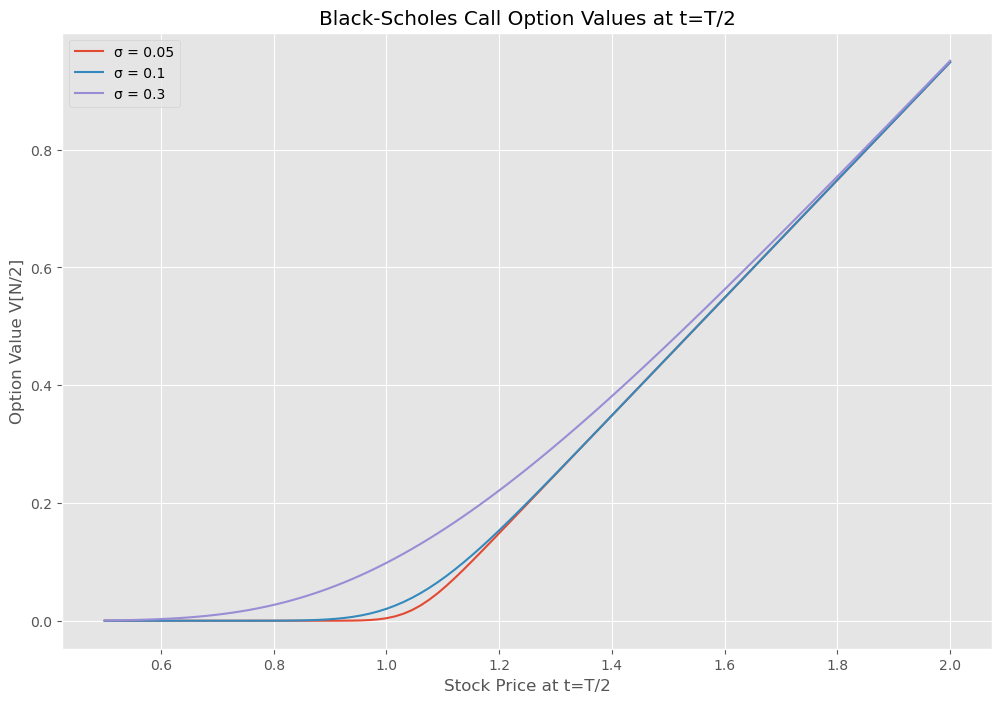

Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 1000
Generated 500 valid paths out of 1000
Generated 600 valid paths out of 1000
Generated 700 valid paths out of 1000
Generated 800 valid paths out of 1000
Generated 900 valid paths out of 1000
Generated 1000 valid paths out of 1000
Completed simulation. Bad paths rejected: 0
Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 1000
Generated 500 valid paths out of 1000
Generated 600 valid paths out of 1000
Generated 700 valid paths out of 1000
Generated 800 valid paths out of 1000
Generated 900 valid paths out of 1000
Generated 1000 valid paths out of 1000
Completed simulation. Bad paths rejected: 0
Generated 100 valid paths out of 1000
Generated 200 valid paths out of 1000
Generated 300 valid paths out of 1000
Generated 400 valid paths out of 100

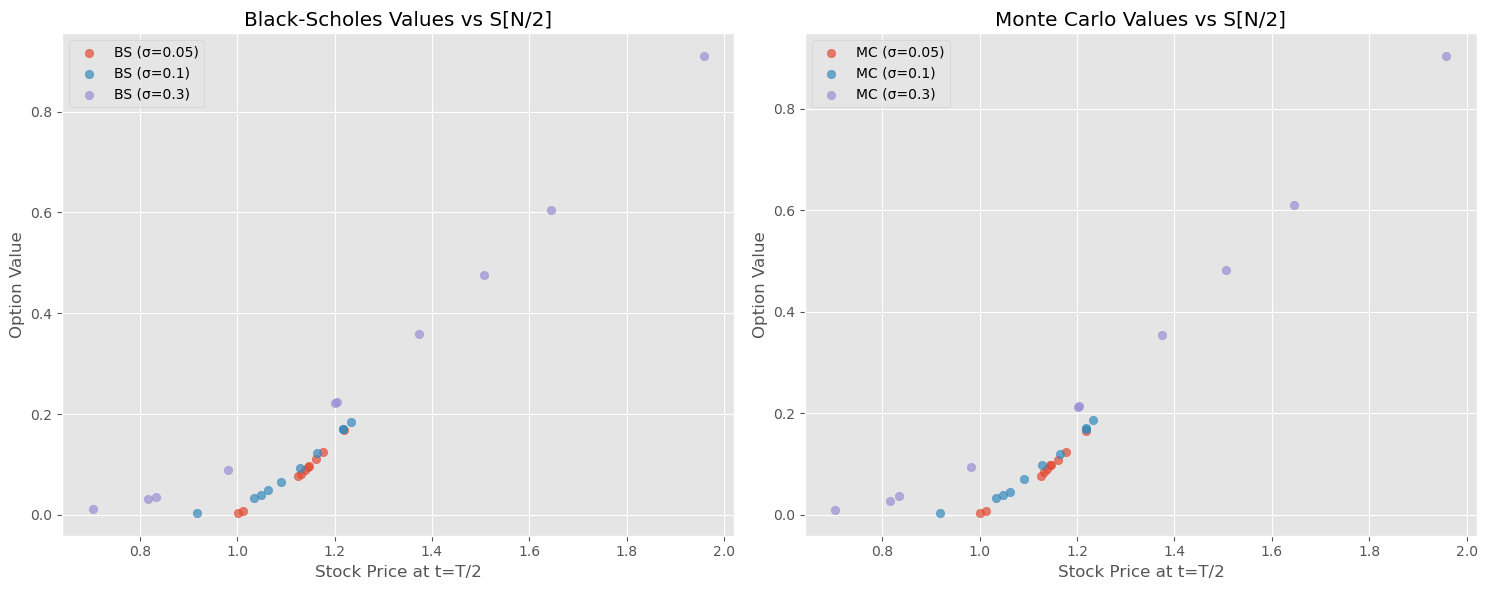

In [18]:
## RUN SIMULATION QUESTION 2
if __name__ == "__main__":
    # Calculate the strike price for the call option
    K = S0 * np.exp(r * T)
    print(f"Strike price K = {K:.4f}")
    
    # Part (b): Calculate risk-neutral SDE coefficients
    for sigma in sigma_values:
        print(f"\nFor σ = {sigma}:")
        risk_neutral_params = derive_risk_neutral_sde(alpha, sigma, r)
    
    # Part (c): Generate 1000 paths for each sigma
    results = simulate_all_sigma_values(S0, alpha, r, sigma_values, T, N, num_paths=1000)
    
    # Part (d): Estimate expectations
    estimate_expectations(results, sigma_values)
    
    # Part (e): Plot Black-Scholes option values
    plot_bs_option_values(S0, r, sigma_values, T)
    
    # Part (f): Compare BS with MC for the first 10 paths
    comparison_df = compare_bs_vs_mc(results, S0, r, sigma_values, T, N)

Part (b): Analyzing direct CIR simulation...
Completed 0/100 trials
Completed 10/100 trials
Completed 20/100 trials
Completed 30/100 trials
Completed 40/100 trials
Completed 50/100 trials
Completed 60/100 trials
Completed 70/100 trials
Completed 80/100 trials
Completed 90/100 trials
Average valid paths out of 1000: 969.14 ± 5.95
Average failure rate: 3.09%

Part (c): Comparing direct and log-transformed simulations...


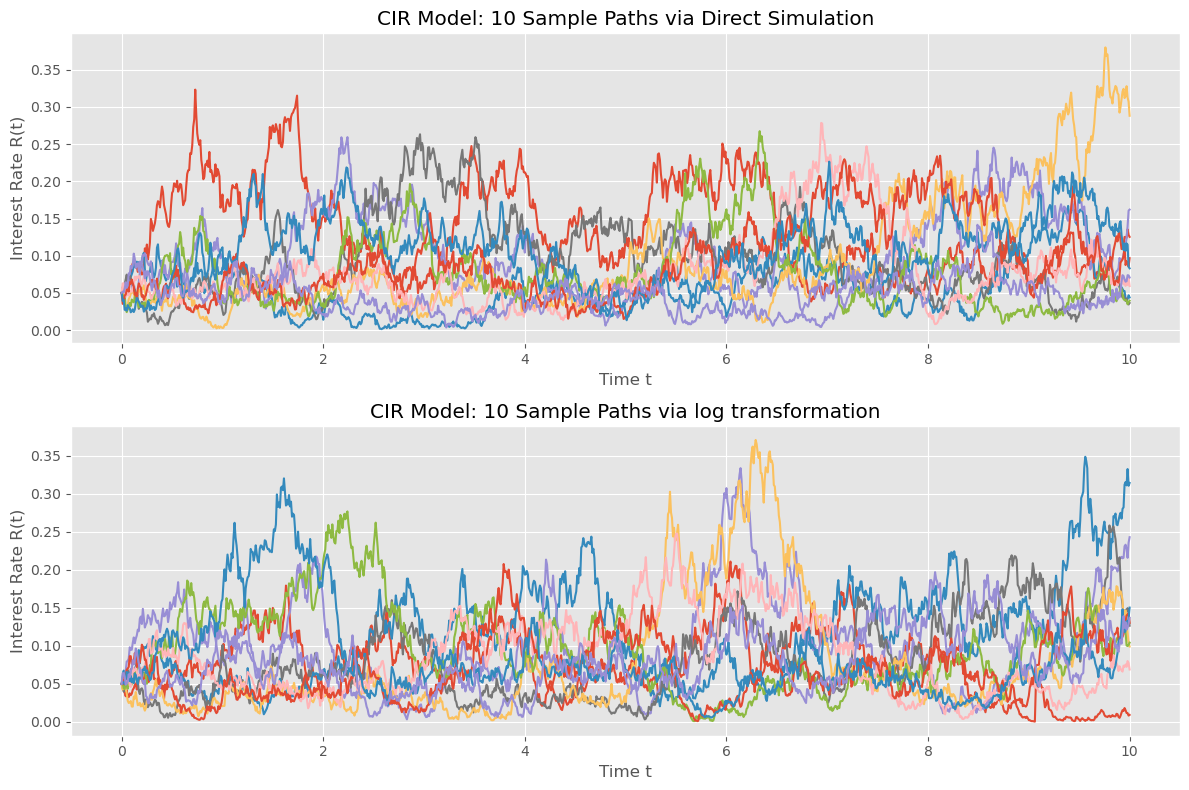


Part (d): Mean comparison table:
   Time  Theoretical Mean  Direct Simulation Mean  Log Simulation Mean  \
0     1          0.081606                0.078252             0.080605   
1     2          0.093233                0.096294             0.153366   
2     3          0.097511                0.099680             0.119203   
3     4          0.099084                0.101014             0.111545   
4     5          0.099663                0.095580             0.102483   
5     6          0.099876                0.096873             0.101902   
6     7          0.099954                0.097509             0.096357   
7     8          0.099983                0.102555             0.098846   
8     9          0.099994                0.100426             0.099778   
9    10          0.099998                0.102346             0.121726   

   Direct Abs Error  Log Abs Error  
0          0.003354       0.001001  
1          0.003061       0.060133  
2          0.002169       0.021692  
3  

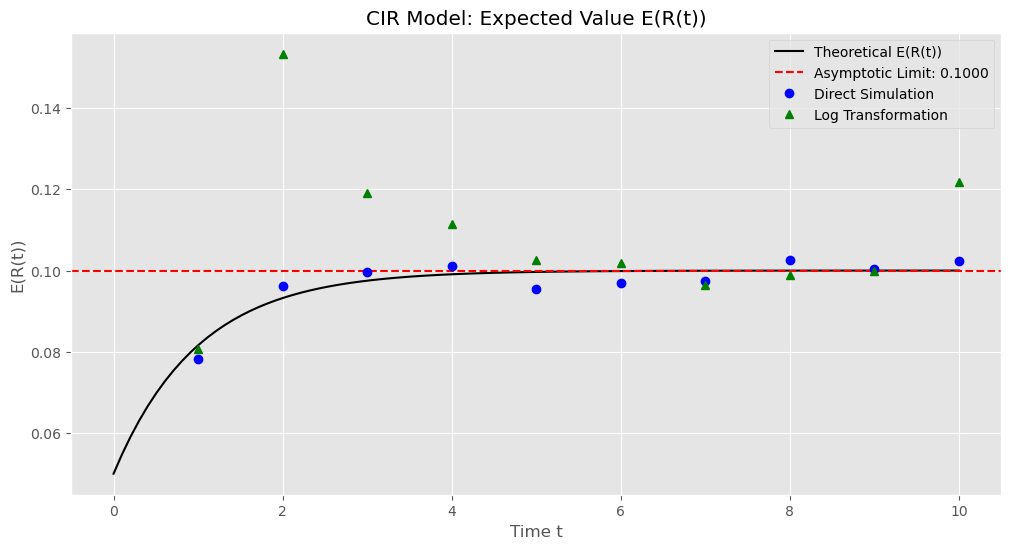

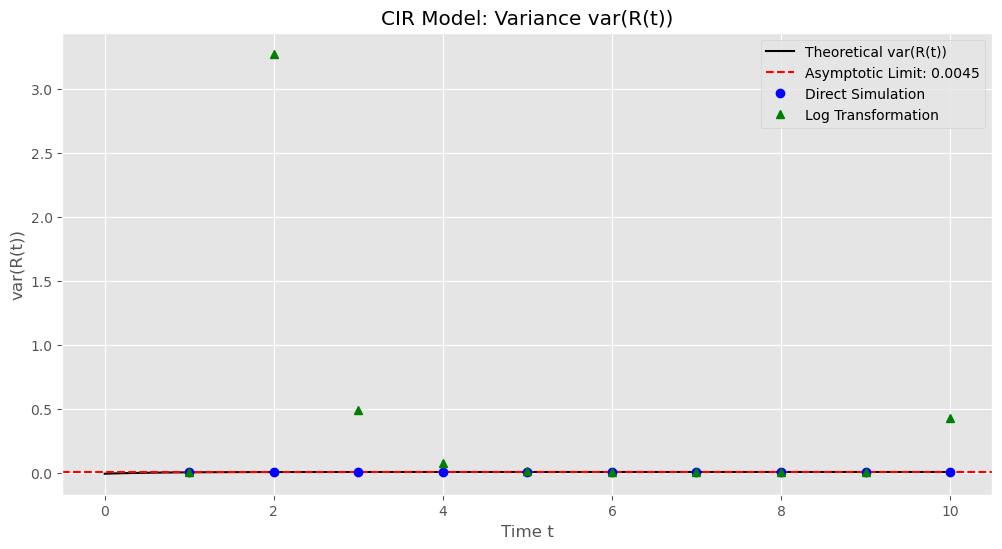

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

# Updated CIR model parameters
beta = 1.0
alpha = 0.10 * beta  # α = 0.10β
r0 = 0.05  # Initial interest rate
sigma = 0.3  # volatility

# Simulation parameters
T = 10.0  # Total time span
delta = 0.01  # Time step
N = int(T / delta)  # Number of time steps
time_grid = np.linspace(0, T, N+1)

# Direct CIR simulation with path validation
def simulate_cir_direct(r0, alpha, beta, sigma, T, N, num_paths=1000):
    """
    Directly simulate the CIR model: dR(t) = (a - β*R(t))dt + σ*sqrt(R(t))dW(t)
    Track and report invalid paths (where R ≤ 0)
    """
    delta = T/N
    time_grid = np.linspace(0, T, N+1)
    
    # Array to store all paths
    R = np.zeros((num_paths, N+1))
    R[:, 0] = r0
    
    # Track valid paths
    valid_paths = np.ones(num_paths, dtype=bool)
    path_failure_time = np.full(num_paths, np.inf)
    
    # Generate paths
    for n in range(N):
        # Generate Wiener increments
        dW = np.random.normal(0, np.sqrt(delta), num_paths)
        
        # Update R using Euler-Maruyama
        dR = (alpha - beta * R[:, n]) * delta + sigma * np.sqrt(np.maximum(0, R[:, n])) * dW
        R[:, n+1] = R[:, n] + dR
        
        # Check for negative values
        invalid = (R[:, n+1] <= 0) & valid_paths
        path_failure_time[invalid] = time_grid[n+1]
        valid_paths[invalid] = False
        
        # Set any negative values to a small positive number to continue simulation
        R[invalid, n+1] = 1e-10
    
    return time_grid, R, np.sum(valid_paths), path_failure_time

# Run multiple trials of direct CIR simulation
def run_cir_direct_trials(r0, alpha, beta, sigma, T, N, num_paths=1000, num_trials=100):
    """
    Run multiple trials of CIR direct simulation and report average valid paths
    """
    valid_counts = []
    
    for i in range(num_trials):
        _, _, valid_count, _ = simulate_cir_direct(r0, alpha, beta, sigma, T, N, num_paths)
        valid_counts.append(valid_count)
        
        if i % 10 == 0:
            print(f"Completed {i}/{num_trials} trials")
    
    avg_valid = np.mean(valid_counts)
    std_valid = np.std(valid_counts)
    
    print(f"Average valid paths out of {num_paths}: {avg_valid:.2f} ± {std_valid:.2f}")
    print(f"Average failure rate: {(num_paths - avg_valid) / num_paths * 100:.2f}%")
    
    return valid_counts

# Simulation via logarithmic transformation
def simulate_cir_via_log(r0, alpha, beta, sigma, T, N, num_paths=1000):
    """
    Simulate the CIR model via X(t) = log(R(t))
    """
    delta = T/N
    time_grid = np.linspace(0, T, N+1)
    
    # Initialize X and R arrays
    X = np.zeros((num_paths, N+1))
    X[:, 0] = np.log(r0)
    R = np.zeros((num_paths, N+1))
    R[:, 0] = r0
    
    # Generate paths
    for n in range(N):
        # Generate Wiener increments
        dW = np.random.normal(0, np.sqrt(delta), num_paths)
        
        # Calculate coefficients based on current X
        R_current = np.exp(X[:, n])
        drift = (alpha / R_current - beta - sigma**2 / (2 * R_current)) * delta
        diffusion = sigma / np.sqrt(R_current) * dW
        
        # Update X
        X[:, n+1] = X[:, n] + drift + diffusion
        
        # Calculate R from X
        R[:, n+1] = np.exp(X[:, n+1])
    
    return time_grid, X, R

# Theoretical CIR model statistics
def theoretical_cir_mean(r0, alpha, beta, t):
    """Calculate theoretical mean for CIR model"""
    return np.exp(-beta * t) * r0 + (alpha / beta) * (1 - np.exp(-beta * t))

def theoretical_cir_var(r0, alpha, beta, sigma, t):
    """Calculate theoretical variance for CIR model"""
    term1 = (sigma**2 / beta) * r0 * (np.exp(-beta * t) - np.exp(-2 * beta * t))
    term2 = (alpha * sigma**2 / (2 * beta**2)) * (1 - 2 * np.exp(-beta * t) - np.exp(-2 * beta * t))
    return term1 + term2

# Run simulations and analyze results
print("Part (b): Analyzing direct CIR simulation...")
valid_counts = run_cir_direct_trials(r0, alpha, beta, sigma, T, N, num_paths=1000, num_trials=100)

print("\nPart (c): Comparing direct and log-transformed simulations...")
# Generate paths using both methods
time_grid_direct, R_direct, _, failure_times = simulate_cir_direct(r0, alpha, beta, sigma, T, N, num_paths=1000)
time_grid_log, X_log, R_log = simulate_cir_via_log(r0, alpha, beta, sigma, T, N, num_paths=1000)

# Plot 10 sample paths from each method
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
for i in range(10):
    plt.plot(time_grid_direct, R_direct[i])
plt.title('CIR Model: 10 Sample Paths via Direct Simulation')
plt.xlabel('Time t')
plt.ylabel('Interest Rate R(t)')
plt.grid(True)

plt.subplot(2, 1, 2)
for i in range(10):
    plt.plot(time_grid_log, R_log[i])
plt.title('CIR Model: 10 Sample Paths via log transformation')
plt.xlabel('Time t')
plt.ylabel('Interest Rate R(t)')
plt.grid(True)

plt.tight_layout()
plt.show()

# Calculate sample statistics at t = 1, 2, ..., 10
sample_times = np.arange(1, 11)
sample_indices = [int(t / delta) for t in sample_times]

# Calculate means and variances
R_means_direct = np.array([np.mean(R_direct[:, idx]) for idx in sample_indices])
R_vars_direct = np.array([np.var(R_direct[:, idx]) for idx in sample_indices])
R_means_log = np.array([np.mean(R_log[:, idx]) for idx in sample_indices])
R_vars_log = np.array([np.var(R_log[:, idx]) for idx in sample_indices])

# Calculate theoretical values
theo_means = np.array([theoretical_cir_mean(r0, alpha, beta, t) for t in sample_times])
theo_vars = np.array([theoretical_cir_var(r0, alpha, beta, sigma, t) for t in sample_times])
asymptotic_mean = alpha / beta
asymptotic_var = (alpha * sigma**2) / (2 * beta**2)

# Create comparison tables
comparison_means = pd.DataFrame({
    'Time': sample_times,
    'Theoretical Mean': theo_means,
    'Direct Simulation Mean': R_means_direct,
    'Log Simulation Mean': R_means_log,
    'Direct Abs Error': np.abs(R_means_direct - theo_means),
    'Log Abs Error': np.abs(R_means_log - theo_means)
})

comparison_vars = pd.DataFrame({
    'Time': sample_times,
    'Theoretical Var': theo_vars,
    'Direct Simulation Var': R_vars_direct,
    'Log Simulation Var': R_vars_log,
    'Direct Abs Error': np.abs(R_vars_direct - theo_vars),
    'Log Abs Error': np.abs(R_vars_log - theo_vars)
})

print("\nPart (d): Mean comparison table:")
print(comparison_means)

print("\nPart (e): Variance comparison table:")
print(comparison_vars)

# Plot mean comparison
plt.figure(figsize=(12, 6))
t_values = np.linspace(0, 10, 100)
theo_mean_curve = [theoretical_cir_mean(r0, alpha, beta, t) for t in t_values]

plt.plot(t_values, theo_mean_curve, 'k-', label='Theoretical E(R(t))')
plt.axhline(y=asymptotic_mean, color='r', linestyle='--', label=f'Asymptotic Limit: {asymptotic_mean:.4f}')
plt.plot(sample_times, R_means_direct, 'bo', label='Direct Simulation')
plt.plot(sample_times, R_means_log, 'g^', label='Log Transformation')

plt.title('CIR Model: Expected Value E(R(t))')
plt.xlabel('Time t')
plt.ylabel('E(R(t))')
plt.legend()
plt.grid(True)
plt.show()

# Plot variance comparison
plt.figure(figsize=(12, 6))
theo_var_curve = [theoretical_cir_var(r0, alpha, beta, sigma, t) for t in t_values]

plt.plot(t_values, theo_var_curve, 'k-', label='Theoretical var(R(t))')
plt.axhline(y=asymptotic_var, color='r', linestyle='--', label=f'Asymptotic Limit: {asymptotic_var:.4f}')
plt.plot(sample_times, R_vars_direct, 'bo', label='Direct Simulation')
plt.plot(sample_times, R_vars_log, 'g^', label='Log Transformation')

plt.title('CIR Model: Variance var(R(t))')
plt.xlabel('Time t')
plt.ylabel('var(R(t))')
plt.legend()
plt.grid(True)
plt.show()

---------
## Section 3: Simulating Jump-Diffusion Processes
---------

Average number of jumps per path: 6.09
Expected number of jumps (λT): 6.00


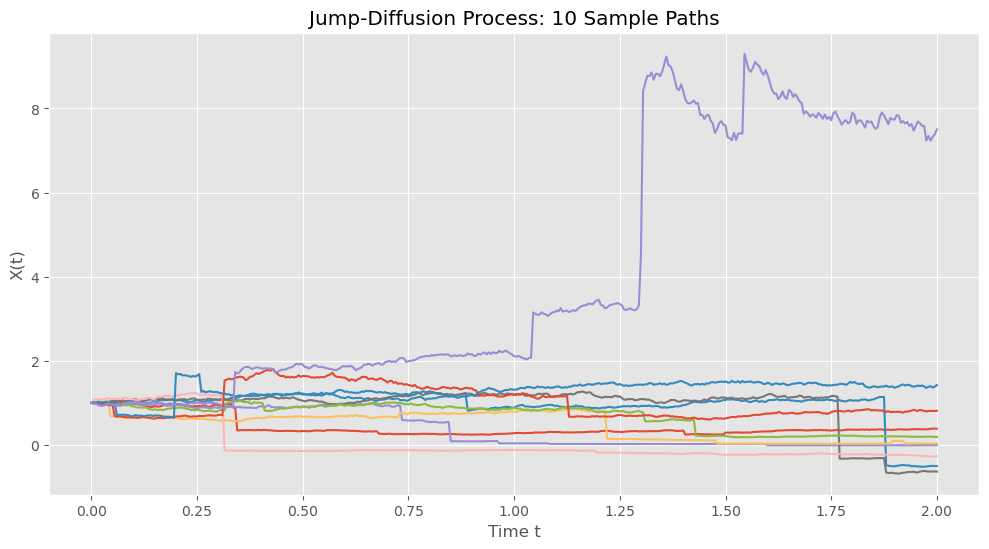

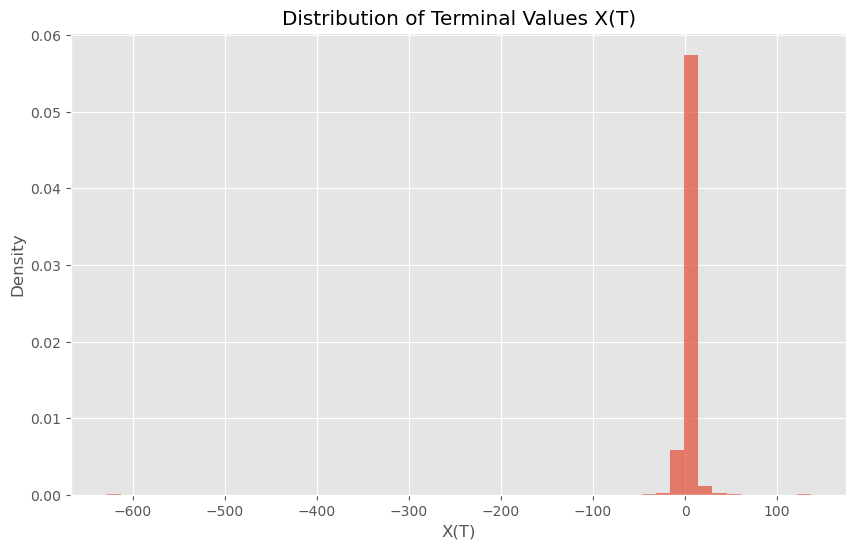

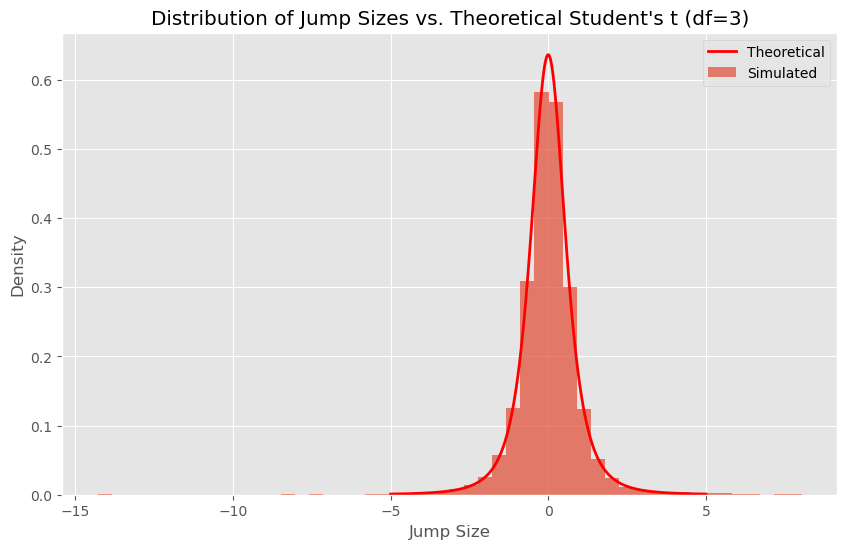

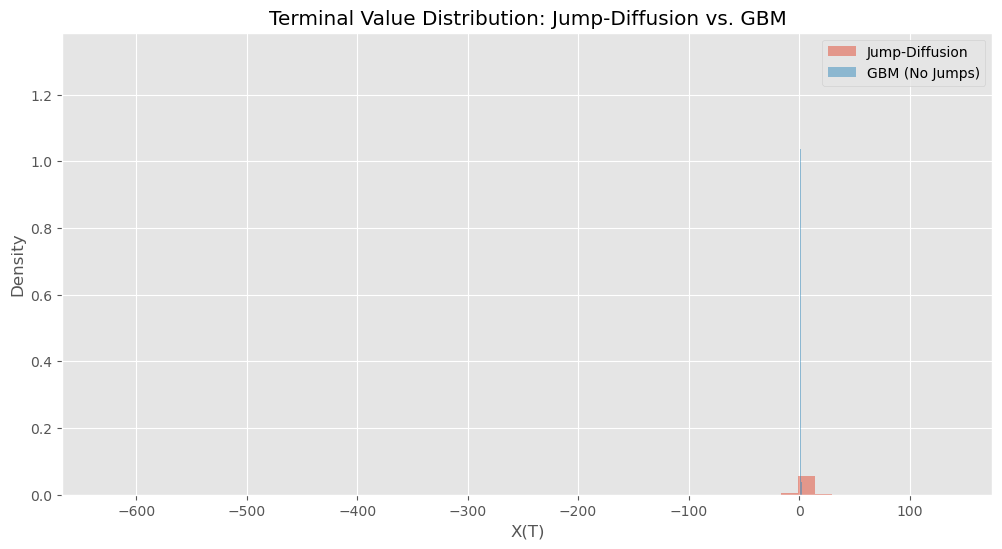


Comparison of terminal value statistics:
            Statistic  Jump-Diffusion  GBM (No Jumps)
0                Mean        0.715936        1.203011
1  Standard Deviation       21.063478        0.362846
2            Skewness      -26.329558        1.122853
3     Excess Kurtosis      795.241283        2.193712


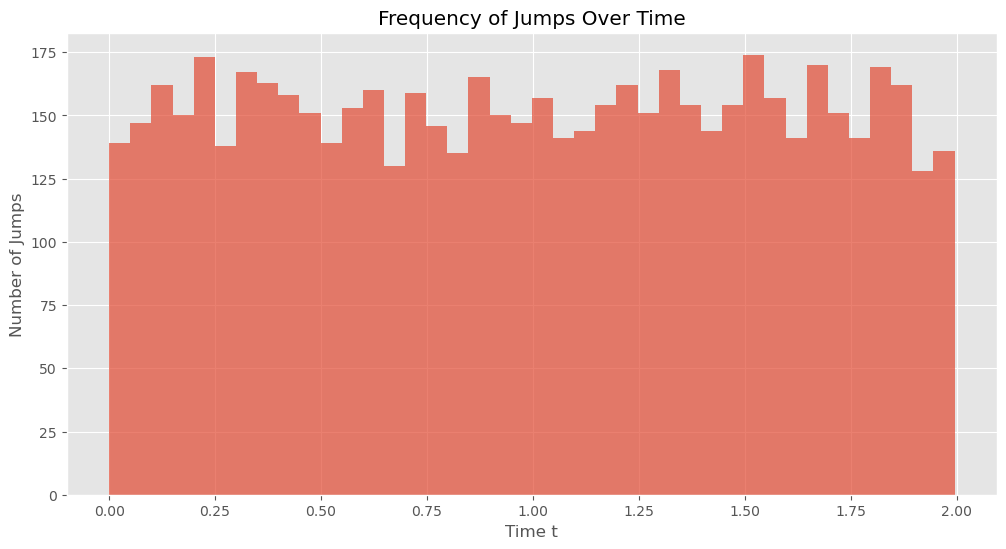


Statistics of X(t) at different times:
   Time      Mean    Std Dev   Skewness  Excess Kurtosis
0   0.5  0.995036   1.805617  -2.463034       136.797001
1   1.0  1.284231   4.658562  10.400663       201.631663
2   1.5  1.110393   6.218203  -4.478286       165.146541
3   2.0  0.715936  21.063478 -26.329558       795.241283


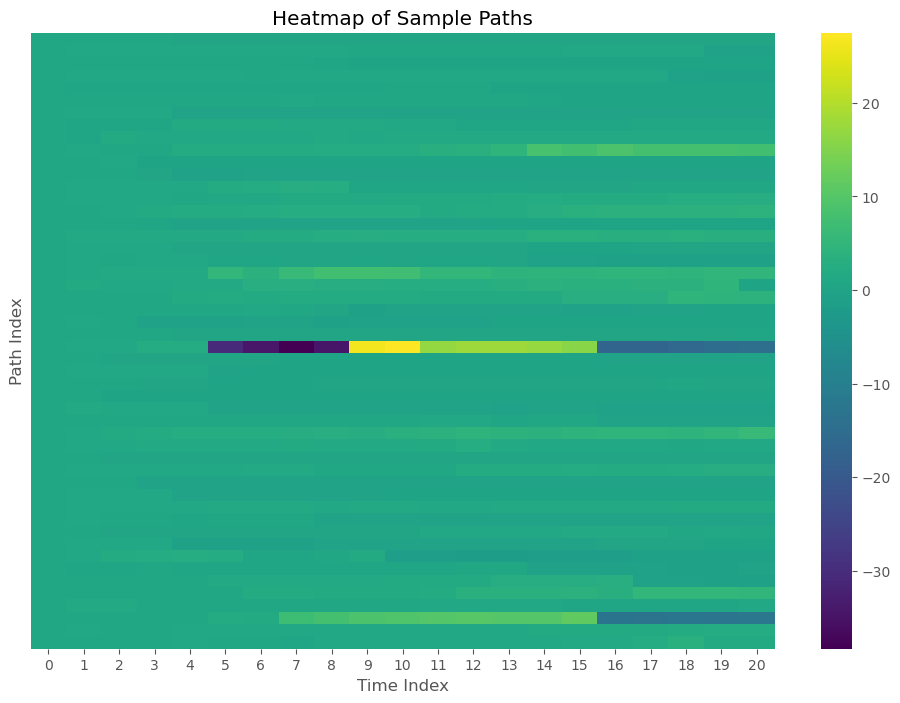

In [3]:
from scipy import stats

alpha = 0.1        # Drift coefficient
sigma = 0.2        # Diffusion coefficient
lambda_rate = 3    # Poisson rate for jumps
dt = 0.005         # Time step
X0 = 1             # Initial value
T = 2              # Final time
N = int(T/dt)      # Number of time steps
num_paths = 1000   # Number of simulation paths

def simulate_jump_diffusion(X0, alpha, sigma, lambda_rate, dt, T, num_paths=1000):
    """
    Simulate the jump-diffusion process:
    dX = αX dt + σX dW + dJ
    
    where J is a pure jump process with Poisson arrival rate λ and
    Student's t-distributed jump sizes (3 degrees of freedom, variance 1).
    """
    N = int(T/dt)
    time_grid = np.linspace(0, T, N+1)
    
    # Initialize paths
    X = np.zeros((num_paths, N+1))
    X[:, 0] = X0
    
    # Student's t distribution with 3 degrees of freedom
    # Scale factor to get variance 1: sqrt(3/1) = sqrt(3)
    df = 3
    scale_factor = np.sqrt(df / (df - 2))  # For variance=1
    
    # Track jump statistics
    total_jumps = 0
    jump_sizes = []
    jump_times = []
    
    # Generate paths
    for n in range(N):
        # Generate standard normal random variables for Brownian motion
        dW = np.random.normal(0, np.sqrt(dt), num_paths)
        
        # Determine if jumps occur at this time step
        jump_occurs = np.random.uniform(0, 1, num_paths) < lambda_rate * dt
        num_jumps_this_step = np.sum(jump_occurs)
        total_jumps += num_jumps_this_step
        
        # Generate jump sizes from Student's t-distribution with 3 dof
        if num_jumps_this_step > 0:
            # Generate t-distributed random variables and scale them
            jump_size = stats.t.rvs(df, size=num_jumps_this_step) / scale_factor
            jump_sizes.extend(jump_size)
            jump_times.extend([time_grid[n]] * num_jumps_this_step)
        
        # Update paths
        dX = alpha * X[:, n] * dt + sigma * X[:, n] * dW
        X[:, n+1] = X[:, n] + dX
        
        # Add jumps
        X[jump_occurs, n+1] += X[jump_occurs, n] * jump_size
    
    # Calculate average number of jumps per path
    avg_jumps_per_path = total_jumps / num_paths
    expected_jumps = lambda_rate * T
    
    print(f"Average number of jumps per path: {avg_jumps_per_path:.2f}")
    print(f"Expected number of jumps (λT): {expected_jumps:.2f}")
    
    return time_grid, X, jump_sizes, jump_times

# Run the simulation
time_grid, X, jump_sizes, jump_times = simulate_jump_diffusion(X0, alpha, sigma, lambda_rate, dt, T, num_paths)

# Plot 10 sample paths
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.plot(time_grid, X[i])
plt.title('Jump-Diffusion Process: 10 Sample Paths')
plt.xlabel('Time t')
plt.ylabel('X(t)')
plt.grid(True)
plt.show()

# Plot histogram of terminal values X(T)
plt.figure(figsize=(10, 6))
plt.hist(X[:, -1], bins=50, alpha=0.7, density=True)
plt.title('Distribution of Terminal Values X(T)')
plt.xlabel('X(T)')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Analyze the jump sizes
plt.figure(figsize=(10, 6))
plt.hist(jump_sizes, bins=50, alpha=0.7, density=True)

# Overlay the theoretical Student's t-distribution (scaled to variance 1)
x = np.linspace(-5, 5, 1000)
df = 3
scale_factor = np.sqrt(df / (df - 2))
pdf = stats.t.pdf(x * scale_factor, df) * scale_factor
plt.plot(x, pdf, 'r-', linewidth=2)

plt.title('Distribution of Jump Sizes vs. Theoretical Student\'s t (df=3)')
plt.xlabel('Jump Size')
plt.ylabel('Density')
plt.legend(['Theoretical', 'Simulated'])
plt.grid(True)
plt.show()

# Compare with GBM (without jumps)
def simulate_gbm(X0, alpha, sigma, dt, T, num_paths=1000):
    """Simulate geometric Brownian motion without jumps"""
    N = int(T/dt)
    time_grid = np.linspace(0, T, N+1)
    
    X = np.zeros((num_paths, N+1))
    X[:, 0] = X0
    
    for n in range(N):
        dW = np.random.normal(0, np.sqrt(dt), num_paths)
        X[:, n+1] = X[:, n] + alpha * X[:, n] * dt + sigma * X[:, n] * dW
    
    return time_grid, X

# Simulate GBM for comparison
time_grid_gbm, X_gbm = simulate_gbm(X0, alpha, sigma, dt, T, num_paths)

# Compare terminal distributions
plt.figure(figsize=(12, 6))
plt.hist(X[:, -1], bins=50, alpha=0.5, density=True, label='Jump-Diffusion')
plt.hist(X_gbm[:, -1], bins=50, alpha=0.5, density=True, label='GBM (No Jumps)')
plt.title('Terminal Value Distribution: Jump-Diffusion vs. GBM')
plt.xlabel('X(T)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Calculate statistics for comparison
jd_mean = np.mean(X[:, -1])
jd_std = np.std(X[:, -1])
jd_skew = stats.skew(X[:, -1])
jd_kurt = stats.kurtosis(X[:, -1])

gbm_mean = np.mean(X_gbm[:, -1])
gbm_std = np.std(X_gbm[:, -1])
gbm_skew = stats.skew(X_gbm[:, -1])
gbm_kurt = stats.kurtosis(X_gbm[:, -1])

# Create a comparison table
stats_comparison = pd.DataFrame({
    'Statistic': ['Mean', 'Standard Deviation', 'Skewness', 'Excess Kurtosis'],
    'Jump-Diffusion': [jd_mean, jd_std, jd_skew, jd_kurt],
    'GBM (No Jumps)': [gbm_mean, gbm_std, gbm_skew, gbm_kurt]
})
print("\nComparison of terminal value statistics:")
print(stats_comparison)

# Analyze jump frequency over time
if jump_times:
    plt.figure(figsize=(12, 6))
    plt.hist(jump_times, bins=40, alpha=0.7)
    plt.title('Frequency of Jumps Over Time')
    plt.xlabel('Time t')
    plt.ylabel('Number of Jumps')
    plt.grid(True)
    plt.show()

# Calculate sample paths statistics at different times
sample_times = [0.5, 1.0, 1.5, 2.0]
sample_indices = [int(t / dt) for t in sample_times]

# Create a dataframe of statistics over time
time_stats = pd.DataFrame({
    'Time': sample_times,
    'Mean': [np.mean(X[:, idx]) for idx in sample_indices],
    'Std Dev': [np.std(X[:, idx]) for idx in sample_indices],
    'Skewness': [stats.skew(X[:, idx]) for idx in sample_indices],
    'Excess Kurtosis': [stats.kurtosis(X[:, idx]) for idx in sample_indices]
})
print("\nStatistics of X(t) at different times:")
print(time_stats)

# Plot a heatmap of sample paths
plt.figure(figsize=(12, 8))
# Sample a subset of paths for visualization
sample_paths = X[:50, ::20]  # 50 paths, sampled every 20 points

# Create a heatmap
sns.heatmap(sample_paths, cmap='viridis', yticklabels=False)
plt.title('Heatmap of Sample Paths')
plt.xlabel('Time Index')
plt.ylabel('Path Index')
plt.show()